In [1]:
import os
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import CharacterTextSplitter

In [2]:
# Load the document
document_dir = "./"
filename = "Book_Serotonin_Schiz.pdf"
file_path = os.path.join(document_dir, filename)

In [3]:
# Load the document and split it into pages
import re

loader = PyPDFLoader(file_path)
pages = loader.load_and_split()

# Preprocess the text: remove extra spaces, special characters, and convert to lowercase

processed_pages = []
for page in pages:
    text = page.page_content
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    text = text.lower()  # Convert to lowercase
    processed_pages.append(text)

# Verify the first processed page
print(processed_pages[0][:1000])
len(pages)

see discussions stats and author profiles for this publication at httpswwwresearchgatenetpublication389135052 serotonin and schizophrenia what inuences what chapter  january 2025 doi 103389fpsyt20241451248 citations 0 reads 5 6 authors including francisco javier jimnez trejo instituto nacional de pediatria 64 publications 612 citations see profile gustavo eduardo canul 12 publications 53 citations see profile all content following this page was uploaded by francisco javier jimnez trejo on 19 february 2025 the user has requested enhancement of the downloaded file


12

In [4]:
# Split the text into chunks
text_splitter = CharacterTextSplitter(chunk_size=2000, chunk_overlap=200)
chunks = text_splitter.split_documents(pages)
len(chunks)

12

In [5]:
# import the embeddings
from langchain_community.embeddings import OpenAIEmbeddings

#loading environment variables
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
# Load the embeddings model
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
api_key = os.getenv("OPENAI_API_KEY")

/var/folders/0v/fj9w0wb16hv195v2v8d8qvr80000gn/T/ipykernel_6550/698871039.py:2: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embeddings = OpenAIEmbeddings(model="text-embedding-3-large")


In [7]:
# import chroma as vector database
from langchain.vectorstores import Chroma

In [8]:
# Create the ChromaDB
db = Chroma.from_documents(chunks, embeddings, persist_directory="./chroma_db")
print("ChromaDB created with document embeddings.")

ChromaDB created with document embeddings.


In [9]:
# Verify the collection name
collection_name = db._collection.name  
print(f"Collection name: {collection_name}")

Collection name: langchain


In [10]:
from collections import Counter
import re

# Inspect the first chunk
print(chunks[3].page_content)

Top 10 Advances in Psychology 
3                                                                                www.videleaf.com 
environmental factors [1]. Several lines of evidence suggest that 
the serotonergic system plays a critical role in the pathogenesis of 
schizophrenia in at least a subpopulation of patients. According to 
the neuropathological changes, this heterogeneous con dition has 
been divided into three main domains: positive symptoms, 
negative symptoms, and cognitive dysfunction. Additionally, 
some researchers have conceptualized schizophrenia as a disease 
of functional “dysconnectivity” [2–4] or “synapse disorder” [5,6], 
affecting the serotonin quantum releasemachinery within the 
synapse during its synthesis, its interaction with its receptors, or 
its correlation with other neurotransmitters (i.e. dopamine, 
glutamate, GABA) [7,8]. Acute relapses of this disease are 
characterised by the exacerbation of positive psychotic symptoms, 
while chronic disabilities

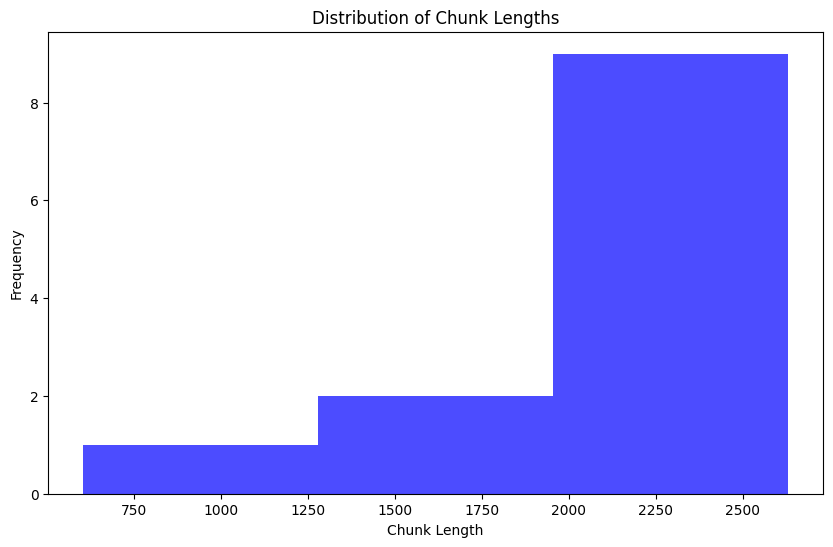

In [11]:
# check distribution of chunk lengths
chunk_lengths = [len(chunk.page_content) for chunk in chunks]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(chunk_lengths, bins=3, color='blue', alpha=0.7)
plt.title("Distribution of Chunk Lengths")
plt.xlabel("Chunk Length")
plt.ylabel("Frequency")
plt.show()

In [12]:
# Extract metadata from the first page
print(pages[0].metadata)

{'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2025-01-29T00:18:41+05:30', 'author': 'welcome', 'moddate': '2025-01-29T00:18:41+05:30', 'rgid': 'PB:389135052_AS:11431281310790090@1739991425267', 'source': './Book_Serotonin_Schiz.pdf', 'total_pages': 12, 'page': 0, 'page_label': '1'}


In [13]:
# Combine all text from chunks
all_text = " ".join(chunk.page_content for chunk in chunks)
print(all_text[:100])

See discussions, stats, and author profiles for this publication at: https://www.researchgate.net/pu


In [14]:
# Tokenize and count words
words = re.findall(r'\w+', all_text.lower())
word_counts = Counter(words)

In [15]:
# Display the most common words
print(word_counts.most_common(10))

[('the', 155), ('of', 123), ('and', 109), ('in', 89), ('schizophrenia', 56), ('a', 44), ('to', 40), ('is', 30), ('as', 30), ('this', 28)]


In [16]:
# Display the length of the text
print(len(all_text))


24844


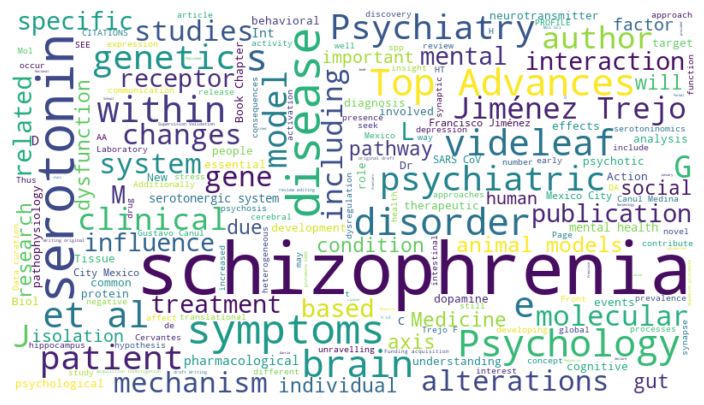

In [ ]:
# Display the word cloud
#pip install wordcloud
import matplotlib.pyplot as plt

from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=450, background_color="white").generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
# Display the most common words
#pip install nltk
import nltk
from nltk.corpus import stopwords
from collections import Counter
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

words = all_text.split()
filtered_words = [word for word in words if word not in stop_words]

# Count word frequency
word_freq = Counter(filtered_words)
print(word_freq.most_common(10)) 


[('schizophrenia', 23), ('The', 18), ('10', 13), ('Top', 12), ('Advances', 12), ('Psychology', 12), ('et', 12), ('al.', 12), ('www.videleaf.com', 11), ('within', 11)]


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/martakarnaschodkiewicz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


/var/folders/0v/fj9w0wb16hv195v2v8d8qvr80000gn/T/ipykernel_6550/3924014712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_words, palette="viridis")


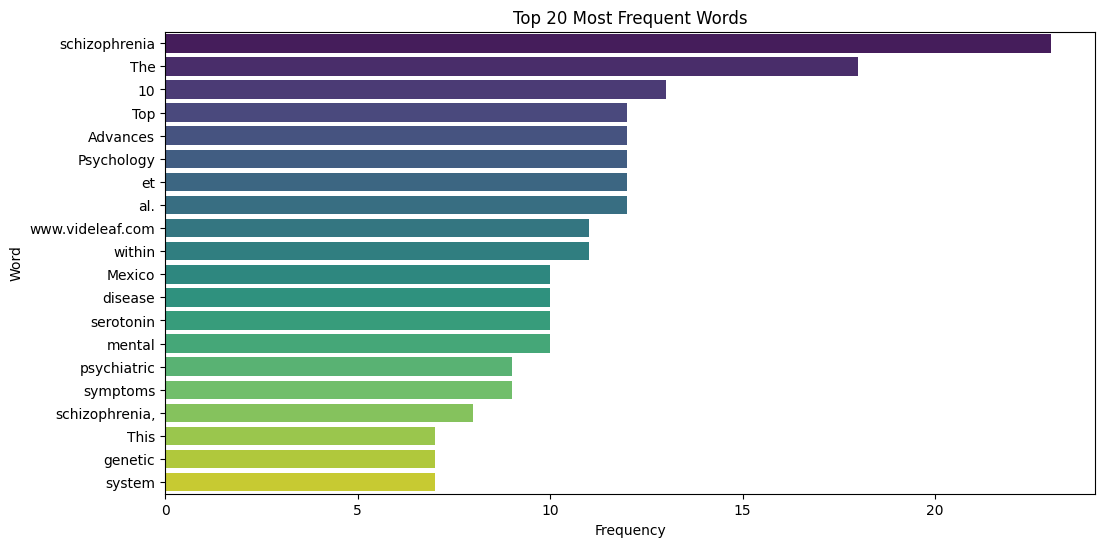

In [ ]:
#pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
df_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Word', data=df_words, palette="viridis")
plt.title("Top 20 Most Frequent Words")
plt.show()

In [20]:
# Display the most common bigrams
user_question = " What is the relation between schizophrenia and serotonin " # User question
retrieved_docs = db.similarity_search(user_question, k=10)
print(f"Retrieved {len(retrieved_docs)} documents.")


Retrieved 10 documents.


In [21]:
# Display the first 4 retrieved documents
for i, doc in enumerate(retrieved_docs[:4]): 
    print(f"Document {i+1}:\n{doc.page_content[36:1000]}")
    

Document 1:
                                                                            www.videleaf.com 
communication within the intestinal microflora but also in 
systemic and peripheral effects that influence brain function [13]. 
 
The reality is that there is a close mutual relationship between 
serotonin and schizophrenia, and this bidirectionally influences 
the way in which serotonin manifests itself in this mental illness. 
But which one comes first: changes in the serotonergic system or 
schizophrenia? This is an important question to which we seek to 
provide an answer in this occasion. 
 
Hierarchy of Action Versus Manifested 
Symptoms  
 
Since its discovery as a molecule by Page et al. in 1948 [14], 
serotonin (5 –hydroxytryptamine, 5 –HT, C 10H12N2O) has led to 
great expectations and interest due to the implications it may have 
for various pathologies, including those related to mental health 
such as schizophrenia. This disease affects million
Document 2:
           

In [22]:
# Display the prompt
def _get_document_prompt(docs):
    prompt = "\n"
    for doc in docs:
        prompt += "\nContent:\n"
        prompt += doc.page_content + "\n\n"
    return prompt

In [23]:
# Format the context for the GPT model
formatted_context = _get_document_prompt(retrieved_docs)
print("Context formatted for GPT model.")

Context formatted for GPT model.


In [ ]:
# Construct the prompt
prompt = f"""
## SYSTEM ROLE
You are a knowledgeable and factual chatbot designed to assist with technical questions about **Schizophrenia**, specifically focusing on **Seratonin Relation**. 
Your answers must be based exclusively on provided content from technical book provided.

## USER QUESTION
The user has asked: 
"{user_question}"

## CONTEXT
Here is the relevant content from the technical book:  
'''
{formatted_context}
'''

## GUIDELINES
1. **Accuracy**:  
   - Only use the content in the `CONTEXT` section to answer.  
   - If the answer cannot be found, explicitly state: "The provided context does not contain this information."
   - Start explaining the relevance of the question in the context of this book
  

## TASK
1. Answer the user's question **directly** if possible.  
2. Point the user to relevant parts of the documentation.  
3. Provide the response in the following format:

## RESPONSE FORMAT
'''
# [Brief Title of the Answer]
[Answer in simple, clear text.]

**Source**:  
• [Book Title], Page(s): [...]
'''
"""
print("Prompt constructed.")

Prompt constructed.
